In [ ]:
pip install Faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 19.2 MB/s eta 0:00:00


In [ ]:
import random
import pandas as pd
from faker import Faker
from datetime import datetime, timedelta
import numpy as np

fake = Faker()
Faker.seed(42)
np.random.seed(42)
random.seed(42)

def generate_legit_transaction():
    base_time = datetime.now() - timedelta(days=random.randint(0, 30))
    return {
        'TXN_TIMESTAMP': base_time + timedelta(minutes=random.randint(0, 1440)),
        'AMOUNT': round(np.random.exponential(1000), 2),
        'TRN_STATUS': random.choice(['Success', 'Failed', 'Pending']),
        'RESPONSE_CODE': random.choice(['0', 'Z7', 'ZM', 'Z9', 'B1', 'YE', 'B3', 'Z6', 'Z8', 'XY', 'V1']),
        'PAYER_VPA': fake.user_name() + '@upi',
        'PAYER_IFSC': 'SBIN000' + str(random.randint(100, 999)),
        'PAYER_ACCOUNT': str(fake.random_number(10, False)),
        'BENEFICIARY_VPA': fake.user_name() + '@upi',
        'BENEFICIARY_IFSC': 'HDFC000' + str(random.randint(100, 999)),
        'BENEFICIARY_ACCOUNT': str(fake.random_number(10, False)),
        'LONGITUDE': round(77 + random.random(), 6),
        'LATITUDE': round(28 + random.random(), 6),
        'DEVICE_ID': 'dev' + str(random.randint(1, 50)),
        'INITIATION_MODE': random.choice(['QR', 'BBPS', 'MANDATE','DEFAULT','INTENT']),
        'TRANSACTION_TYPE': random.choice(['P2P', 'P2M']),
        'PAYMENT_INSTRUMENT': random.choice(['UPI']),
        'IP_ADDRESS': fake.ipv4(),
        'IS_FRAUD': 0
    }


In [ ]:
def generate_fraud_transaction():
    txn = generate_legit_transaction()
    txn['AMOUNT'] = round(random.uniform(5000, 100000), 2)  # spike
    txn['LONGITUDE'] += random.uniform(2.0, 5.0)  # sudden geo-jump
    txn['LATITUDE'] += random.uniform(2.0, 5.0)
    txn['DEVICE_ID'] = 'unknown_dev_' + str(random.randint(100, 200))
    txn['IP_ADDRESS'] = fake.ipv4_private()
    txn['IS_FRAUD'] = 1
    return txn


In [ ]:
legit = [generate_legit_transaction() for _ in range(14800)]
fraud = [generate_fraud_transaction() for _ in range(200)]
data = pd.DataFrame(legit + fraud)
data = data.sample(frac=1).reset_index(drop=True)  # shuffle


In [ ]:
data

,TXN_TIMESTAMP,AMOUNT,TRN_STATUS,RESPONSE_CODE,PAYER_VPA,PAYER_IFSC,PAYER_ACCOUNT,BENEFICIARY_VPA,BENEFICIARY_IFSC,BENEFICIARY_ACCOUNT,LONGITUDE,LATITUDE,DEVICE_ID,INITIATION_MODE,TRANSACTION_TYPE,PAYMENT_INSTRUMENT,IP_ADDRESS,IS_FRAUD
0,2025-05-23 13:40:59.161877,779.44,Success,XY,ashleyflores@upi,SBIN000888,5851514280,andrewjones@upi,HDFC000534,2363973797,77.640173,28.467392,dev27,MANDATE,P2P,UPI,60.5.243.122,0
1,2025-04-27 05:54:01.738299,1555.92,Failed,Z7,ksalazar@upi,SBIN000621,1521873223,lewisrebecca@upi,HDFC000676,2968654656,77.939727,28.551564,dev48,QR,P2P,UPI,178.106.236.85,0
2,2025-05-21 09:16:00.768861,237.72,Pending,Z6,nschroeder@upi,SBIN000939,8147794194,yschultz@upi,HDFC000781,3095949301,77.744029,28.759534,dev29,DEFAULT,P2P,UPI,12.118.246.209,0
3,2025-05-17 23:17:56.972708,1047.89,Pending,V1,yfox@upi,SBIN000297,8883058700,alewis@upi,HDFC000248,6761100005,77.952847,28.531889,dev3,MANDATE,P2P,UPI,146.152.205.135,0
4,2025-05-23 14:26:00.476947,1306.62,Failed,Z6,gsanders@upi,SBIN000292,7573372817,kara49@upi,HDFC000149,4925238424,77.321277,28.428124,dev13,INTENT,P2P,UPI,123.3.203.85,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,2025-05-16 07:35:00.517165,561.87,Failed,YE,joshua38@upi,SBIN000889,88583209,pgonzalez@upi,HDFC000802,9181421520,77.195799,28.248939,dev8,INTENT,P2P,UPI,4.42.129.66,0
14996,2025-04-28 12:44:59.039138,60.32,Success,B1,claudiaharris@upi,SBIN000850,2550464635,omccall@upi,HDFC000129,7523597189,77.878774,28.086181,dev21,INTENT,P2P,UPI,39.114.8.110,0
14997,2025-04-29 07:54:56.932665,312.70,Pending,ZM,gilldakota@upi,SBIN000215,4776936342,palvarez@upi,HDFC000102,3381627305,77.850101,28.224331,dev31,QR,P2P,UPI,6.193.42.65,0
14998,2025-04-27 10:58:58.291269,626.01,Failed,V1,ccarlson@upi,SBIN000347,4401708036,earldavidson@upi,HDFC000493,5318041635,77.878571,28.978449,dev42,DEFAULT,P2P,UPI,78.214.55.235,0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data_test = pd.read_csv('/content/drive/MyDrive/Load_forecasting_dataset/anonymized_sample_fraud_txn.csv')

In [ ]:
data_test.PAYMENT_INSTRUMENT.unique()

array(['UPI'], dtype=object)

In [ ]:
df = data_test.copy()

In [ ]:
df.head()

,TXN_TIMESTAMP,TRANSACTION_ID,RRN,TRN_STATUS,AMOUNT,RESPONSE_CODE,PAYER_VPA,PAYER_CODE,PAYER_IFSC,PAYER_ACCOUNT,...,LONGITUDE,LATITUDE,DEVICE_ID,INITIATION_MODE,UPI_LITE_LRN,CARD_NUMBER,TRANSACTION_TYPE,PAYMENT_INSTRUMENT,IP_ADDRESS,IS_FRAUD
0,01/03/2025 13:51,c9bf0472742251ad80fe,762184f5397b8ec020f1,COMPLETED,1.0,0,e3b9072ba0be9291d0c4@axl,0,ff672a0c87c64a83e142,e762528cd21317b6ea21,...,8hoIOh10A7Qq76/YclrTVQ==,wGG9nld0Q1KYo4oU+a50Tg==,QYCDG0GPMDCY2NRXDMMLLOZC5YAC1EJSD2T,Default,NaN,NaN,P2P,UPI,1db5d33a79fe928f2947,0
1,01/03/2025 22:10,5faeb3453a0976f8c694,78985f52b9a1ebd74fe5,COMPLETED,250.0,0,fe7e02e4f383114f5db0@centralbank,0,28088b1f2f48bbdd8453,3e710cfae1f96a9a87e7,...,34BbQlLIagwmaErKqKsSTQ==,a8269HK8vua90V+joxjBIg==,25f6dde356db5125,Default,NaN,NaN,P2P,UPI,aeb88df774e26e92b409,0
2,02/03/2025 16:46,109837b52fea98ec8d34,b73c128d930c92815edd,COMPLETED,500.0,0,fe7e02e4f383114f5db0@centralbank,0,28088b1f2f48bbdd8453,3e710cfae1f96a9a87e7,...,Q7VnE9X/qJaFKOgqdpK7dQ==,DwM8wnOmUby6dhZnkjtoSg==,25f6dde356db5125,Default,NaN,NaN,P2P,UPI,419029d115ced5602a5c,0
3,03/03/2025 12:53,4636d2431685ccb999b9,ce19533f5f3e21d25d65,COMPLETED,10000.0,0,d485f4ea4b3327917d9c@pthdfc,0,05877e798bf097ac74cc,cd181fa5c60010afb675,...,Zq5yGzk39Ck8rrF1e96Scw==,f+DFJyDvJxOabkOYvmjiTQ==,7394c52d3fada667,Default,NaN,NaN,P2P,UPI,4dab9eda506526f217f8,0
4,05/03/2025 22:05,009036513541c903d2c1,9952cbfdeb8b72a2e4e2,COMPLETED,10000.0,0,c6673f3dfea8a58492b8@okhdfcbank,0,05877e798bf097ac74cc,cd181fa5c60010afb675,...,dmqpU7wj0yi6/zyY4oAFKA==,xDuIaJEN29vtxYAS1SXStw==,2e773d08f0da663c,Default,NaN,NaN,P2P,UPI,070fef5f43ad5315bb6f,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2881 entries, 0 to 2880
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TXN_TIMESTAMP        2881 non-null   object 
 1   TRANSACTION_ID       2881 non-null   object 
 2   RRN                  2881 non-null   object 
 3   TRN_STATUS           2881 non-null   object 
 4   AMOUNT               2881 non-null   float64
 5   RESPONSE_CODE        2881 non-null   object 
 6   PAYER_VPA            2881 non-null   object 
 7   PAYER_CODE           2881 non-null   int64  
 8   PAYER_IFSC           2881 non-null   object 
 9   PAYER_ACCOUNT        2881 non-null   object 
 10  BENEFICIARY_VPA      2881 non-null   object 
 11  BENEFICIARY_CODE     2881 non-null   int64  
 12  BENEFICIARY_IFSC     2830 non-null   object 
 13  BENEFICIARY_ACCOUNT  2830 non-null   object 
 14  LONGITUDE            2858 non-null   object 
 15  LATITUDE             2858 non-null   o

 'AMOUNT', 'TRN_STATUS', 'RESPONSE_CODE', 'INITIATION_MODE', 'TRANSACTION_TYPE',
    'PAYER_VPA_freq', 'PAYER_IFSC_freq', 'PAYER_ACCOUNT_freq',
    'BENEFICIARY_CODE_freq', 'BENEFICIARY_IFSC_freq', 'BENEFICIARY_ACCOUNT_freq',
    'LONGITUDE_freq', 'LATITUDE_freq', 'hour', 'day_of_week',
    'is_night', 'txn_count_1h', 'avg_amount_user', 'spending_spike',
    'geo_distance_from_last', 'unusual_location',
    'new_device_flag', 'is_first_transaction'

In [ ]:
for col in df:
  print(col,len(df[col].unique()))

TXN_TIMESTAMP 2364
TRANSACTION_ID 2881
RRN 2881
TRN_STATUS 2
AMOUNT 609
RESPONSE_CODE 11
PAYER_VPA 500
PAYER_CODE 1
PAYER_IFSC 156
PAYER_ACCOUNT 167
BENEFICIARY_VPA 1727
BENEFICIARY_CODE 118
BENEFICIARY_IFSC 731
BENEFICIARY_ACCOUNT 980
LONGITUDE 915
LATITUDE 914
DEVICE_ID 312
INITIATION_MODE 11
UPI_LITE_LRN 7
CARD_NUMBER 1
TRANSACTION_TYPE 2
PAYMENT_INSTRUMENT 1
IP_ADDRESS 1283
IS_FRAUD 2


In [ ]:
df.describe()

,AMOUNT,PAYER_CODE,BENEFICIARY_CODE,CARD_NUMBER,IS_FRAUD
count,2881.000000,2881.0,2881.000000,0.0,2881.000000
mean,3781.340382,0.0,2932.528289,NaN,0.132593
std,9240.480946,0.0,2867.131596,NaN,0.339193
min,1.000000,0.0,0.000000,NaN,0.000000
25%,64.000000,0.0,0.000000,NaN,0.000000
50%,500.000000,0.0,4784.000000,NaN,0.000000
75%,2500.000000,0.0,5441.000000,NaN,0.000000
max,100000.000000,0.0,9400.000000,NaN,1.000000


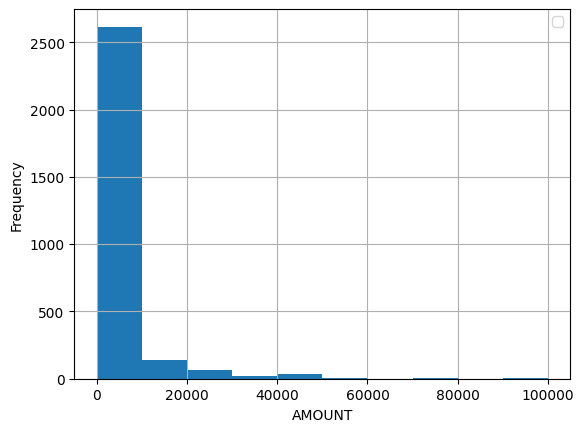

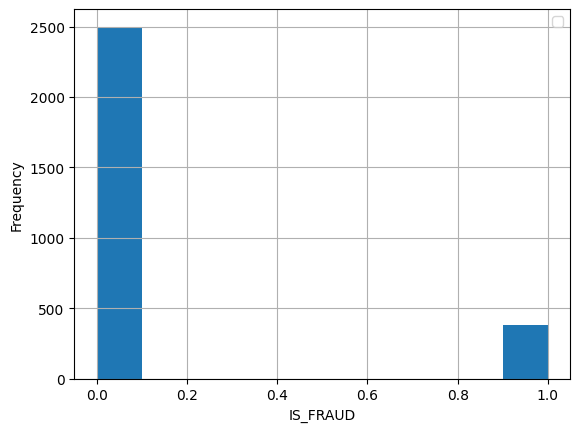

In [ ]:
columns = ['AMOUNT','IS_FRAUD']
for col in columns:
  plt.figure()
  plt.legend(col)
  df[col].hist()
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()



In [ ]:
drop_col=['CARD_NUMBER', 'PAYMENT_INSTRUMENT', 'PAYER_CODE','UPI_LITE_LRN', 'BENEFICIARY_CODE']
df.drop(columns=drop_col, inplace=True,errors='ignore')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
label_encoded_cols = ['TRN_STATUS', 'RESPONSE_CODE', 'INITIATION_MODE', 'TRANSACTION_TYPE']

for col in label_encoded_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
df.TRANSACTION_TYPE.value_counts()
# P2P, P2M

,count
TRANSACTION_TYPE,
0,1514
1,1367


In [ ]:
frequency_encoded_cols = [
    'AMOUNT', 'PAYER_VPA', 'PAYER_IFSC', 'PAYER_ACCOUNT', 'BENEFICIARY_IFSC', 'BENEFICIARY_ACCOUNT',
    'LONGITUDE', 'LATITUDE', 'DEVICE_ID'
]

for col in frequency_encoded_cols:
    freq_map = df[col].value_counts().to_dict()
    df[f'{col}_freq'] = df[col].map(freq_map)


In [ ]:
high_card_cols = ['TXN_TIMESTAMP', 'TRANSACTION_ID', 'RRN', 'BENEFICIARY_VPA', 'IP_ADDRESS']
# Do not use directly in model — instead, extract features from them (like time features)


In [ ]:
df.AMOUNT_freq

,AMOUNT_freq
0,88
1,20
2,90
3,69
4,69
...,...
2876,1
2877,134
2878,134
2879,134


Feature Engineering

In [ ]:
df['TXN_TIMESTAMP']

,TXN_TIMESTAMP
0,01/03/2025 13:51
1,01/03/2025 22:10
2,02/03/2025 16:46
3,03/03/2025 12:53
4,05/03/2025 22:05
...,...
2876,08/03/2025 18:09
2877,09/03/2025 08:02
2878,09/03/2025 07:53
2879,09/03/2025 07:52


In [ ]:
# Day/Time features
df['TXN_TIMESTAMP'] = pd.to_datetime(df['TXN_TIMESTAMP'], format='%d/%m/%Y %H:%M')
df['hour'] = df['TXN_TIMESTAMP'].dt.hour
df['day_of_week'] = df['TXN_TIMESTAMP'].dt.dayofweek
df['is_night'] = df['hour'].apply(lambda x: 1 if x < 6 or x > 22 else 0)


In [ ]:
df.head()

,TXN_TIMESTAMP,TRANSACTION_ID,RRN,TRN_STATUS,AMOUNT,RESPONSE_CODE,PAYER_VPA,PAYER_IFSC,PAYER_ACCOUNT,BENEFICIARY_VPA,...,PAYER_IFSC_freq,PAYER_ACCOUNT_freq,BENEFICIARY_IFSC_freq,BENEFICIARY_ACCOUNT_freq,LONGITUDE_freq,LATITUDE_freq,DEVICE_ID_freq,hour,day_of_week,is_night
0,2025-03-01 13:51:00,c9bf0472742251ad80fe,762184f5397b8ec020f1,0,1.0,0,e3b9072ba0be9291d0c4@axl,ff672a0c87c64a83e142,e762528cd21317b6ea21,d1030091030967ba0a0e@axl,...,5,5,1.0,1.0,1.0,1.0,5,13,5,0
1,2025-03-01 22:10:00,5faeb3453a0976f8c694,78985f52b9a1ebd74fe5,0,250.0,0,fe7e02e4f383114f5db0@centralbank,28088b1f2f48bbdd8453,3e710cfae1f96a9a87e7,46cbdf13adb6fcdacd91@cbin,...,96,96,4.0,4.0,2.0,2.0,38,22,5,0
2,2025-03-02 16:46:00,109837b52fea98ec8d34,b73c128d930c92815edd,0,500.0,0,fe7e02e4f383114f5db0@centralbank,28088b1f2f48bbdd8453,3e710cfae1f96a9a87e7,46cbdf13adb6fcdacd91@cbin,...,96,96,4.0,4.0,1.0,1.0,38,16,6,0
3,2025-03-03 12:53:00,4636d2431685ccb999b9,ce19533f5f3e21d25d65,0,10000.0,0,d485f4ea4b3327917d9c@pthdfc,05877e798bf097ac74cc,cd181fa5c60010afb675,d485f4ea4b3327917d9c@pthdfc,...,6,6,2.0,2.0,1.0,1.0,2,12,0,0
4,2025-03-05 22:05:00,009036513541c903d2c1,9952cbfdeb8b72a2e4e2,0,10000.0,0,c6673f3dfea8a58492b8@okhdfcbank,05877e798bf097ac74cc,cd181fa5c60010afb675,0e5ea6b910ce164dfa54@okicici,...,6,6,1.0,1.0,2.0,2.0,3,22,2,0


In [ ]:
#  Transaction velocity features

# Sort data for rolling calculations
df= df.sort_values(by=['PAYER_VPA','TXN_TIMESTAMP'])

# Rolling count of transactions in past 1 hour per user
for payer in df['PAYER_VPA'].unique():
    user_df = df[df['PAYER_VPA'] == payer]
    timestamps = user_df['TXN_TIMESTAMP'].tolist()
    counts = []
    for i in range(len(timestamps)):
        t1 = timestamps[i]
        window_start = t1 - pd.Timedelta(hours=1)
        count = sum((t >= window_start) and (t < t1) for t in timestamps[:i])
        counts.append(count)
    df.loc[df['PAYER_VPA'] == payer, 'txn_count_1h'] = counts

# Average amount per user
df['avg_amount_user'] = df.groupby('PAYER_VPA')['AMOUNT'].transform('mean')

# Spike indicator (if current amount is 3x higher than user average)
df['spending_spike'] = (df['AMOUNT'] > 3 * df['avg_amount_user']).astype(int)


In [ ]:
df.describe()

,TXN_TIMESTAMP,TRN_STATUS,AMOUNT,RESPONSE_CODE,INITIATION_MODE,TRANSACTION_TYPE,IS_FRAUD,AMOUNT_freq,PAYER_VPA_freq,PAYER_IFSC_freq,...,BENEFICIARY_ACCOUNT_freq,LONGITUDE_freq,LATITUDE_freq,DEVICE_ID_freq,hour,day_of_week,is_night,txn_count_1h,avg_amount_user,spending_spike
count,2881,2881.000000,2881.000000,2881.000000,2881.000000,2881.000000,2881.000000,2881.000000,2881.000000,2881.000000,...,2830.000000,2858.000000,2858.000000,2881.000000,2881.000000,2881.000000,2881.000000,2881.000000,2881.000000,2881.000000
mean,2025-03-05 15:02:10.433877248,0.205831,3781.340382,1.447067,3.351614,0.474488,0.132593,43.065255,14.825061,33.754599,...,124.969611,122.097971,121.626312,23.007636,14.005554,3.477959,0.062131,0.550156,3781.340382,0.066296
min,2025-03-01 00:07:00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2025-03-03 14:28:00,0.000000,64.000000,0.000000,1.000000,0.000000,0.000000,5.000000,5.000000,16.000000,...,2.000000,2.000000,2.000000,9.000000,11.000000,2.000000,0.000000,0.000000,516.680000,0.000000
50%,2025-03-05 17:00:00,0.000000,500.000000,0.000000,3.000000,0.000000,0.000000,22.000000,12.000000,29.000000,...,6.000000,6.000000,6.000000,18.000000,14.000000,4.000000,0.000000,0.000000,1499.384615,0.000000
75%,2025-03-07 14:49:00,0.000000,2500.000000,0.000000,6.000000,1.000000,0.000000,83.000000,22.000000,42.000000,...,328.000000,349.000000,349.000000,31.000000,18.000000,5.000000,0.000000,1.000000,4853.750000,0.000000
max,2025-03-09 23:28:00,1.000000,100000.000000,10.000000,10.000000,1.000000,1.000000,134.000000,50.000000,108.000000,...,468.000000,416.000000,416.000000,110.000000,23.000000,6.000000,1.000000,15.000000,95000.000000,1.000000
std,NaN,0.404378,9240.480946,3.009140,2.512387,0.499435,0.339193,43.135839,11.869865,25.036068,...,183.393318,166.461622,166.565261,21.491438,4.941249,1.959915,0.241436,1.309554,6473.956322,0.248843


In [ ]:
# import base64
# import hashlib
# import pandas as pd
# import numpy as np

# def hash_based_decode_single(encoded_coord):
#     """
#     Decode a single coordinate using hash-based method.

#     Args:
#         encoded_coord (str): Base64-encoded coordinate

#     Returns:
#         float: Decoded coordinate value
#     """
#     try:
#         # Decode base64 to bytes
#         coord_bytes = base64.b64decode(encoded_coord)

#         # Create hash from the bytes
#         coord_hash = hashlib.sha256(coord_bytes).digest()

#         # Convert first 8 bytes of hash to coordinate
#         # For latitude: range -90 to 90
#         # For longitude: range -180 to 180
#         coord_int = int.from_bytes(coord_hash[:8], 'big')

#         return coord_int

#     except Exception as e:
#         print(f"Error decoding {encoded_coord}: {e}")
#         return np.nan

# def decode_latitude_hash(encoded_lat):
#     """Decode latitude using hash method (range -90 to 90)"""
#     coord_int = hash_based_decode_single(encoded_lat)
#     if pd.isna(coord_int):
#         return np.nan
#     # Scale to latitude range -90 to 90
#     return (coord_int % 180000000) / 1000000 - 90

# def decode_longitude_hash(encoded_lng):
#     """Decode longitude using hash method (range -180 to 180)"""
#     coord_int = hash_based_decode_single(encoded_lng)
#     if pd.isna(coord_int):
#         return np.nan
#     # Scale to longitude range -180 to 180
#     return (coord_int % 360000000) / 1000000 - 180

# def decode_coordinates_dataframe(df, lat_col='LATITUDE', lng_col='LONGITUDE'):
#     """
#     Decode encoded coordinates in a pandas DataFrame.

#     Args:
#         df (pd.DataFrame): DataFrame with encoded coordinates
#         lat_col (str): Name of latitude column
#         lng_col (str): Name of longitude column

#     Returns:
#         pd.DataFrame: DataFrame with decoded coordinates
#     """
#     # Create a copy to avoid modifying original
#     df_decoded = df.copy()

#     print(f"Decoding {len(df)} coordinate pairs...")
#     print(f"Latitude column: {lat_col}")
#     print(f"Longitude column: {lng_col}")

#     # Check if columns exist
#     if lat_col not in df.columns:
#         raise ValueError(f"Column '{lat_col}' not found in DataFrame")
#     if lng_col not in df.columns:
#         raise ValueError(f"Column '{lng_col}' not found in DataFrame")

#     # Decode coordinates
#     print("Decoding latitudes...")
#     df_decoded[f'{lat_col}_DECODED'] = df_decoded[lat_col].apply(decode_latitude_hash)

#     print("Decoding longitudes...")
#     df_decoded[f'{lng_col}_DECODED'] = df_decoded[lng_col].apply(decode_longitude_hash)

#     # Add validation column
#     df_decoded['COORDINATES_VALID'] = (
#         (df_decoded[f'{lat_col}_DECODED'].between(-90, 90)) &
#         (df_decoded[f'{lng_col}_DECODED'].between(-180, 180)) &
#         (~df_decoded[f'{lat_col}_DECODED'].isna()) &
#         (~df_decoded[f'{lng_col}_DECODED'].isna())
#     )

#     return df_decoded

# def alternative_hash_methods(df, lat_col='LATITUDE', lng_col='LONGITUDE', sample_size=5):
#     """
#     Try alternative hash-based decoding methods on a sample of the data.
#     Use this if the main method doesn't work well.
#     """
#     sample_df = df.head(sample_size).copy()

#     print(f"Testing alternative hash methods on {sample_size} samples...")

#     methods = {
#         'method_1': lambda x: (int.from_bytes(hashlib.sha256(base64.b64decode(x)).digest()[:8], 'big') % 180000000) / 1000000 - 90,
#         'method_2': lambda x: (int.from_bytes(hashlib.sha256(base64.b64decode(x)).digest()[:8], 'little') % 180000000) / 1000000 - 90,
#         'method_3': lambda x: (int.from_bytes(hashlib.md5(base64.b64decode(x)).digest()[:8], 'big') % 180000000) / 1000000 - 90,
#         'method_4': lambda x: (int.from_bytes(base64.b64decode(x)[:8], 'big') % 180000000) / 1000000 - 90,
#         'method_5': lambda x: (int.from_bytes(base64.b64decode(x)[8:], 'big') % 180000000) / 1000000 - 90,
#     }

#     for method_name, method_func in methods.items():
#         try:
#             sample_df[f'lat_{method_name}'] = sample_df[lat_col].apply(method_func)
#             # Adjust for longitude range
#             sample_df[f'lng_{method_name}'] = sample_df[lng_col].apply(
#                 lambda x: (method_func(x) + 90) * 2 - 180  # Convert lat range to lng range
#             )

#             valid_count = sum(
#                 sample_df[f'lat_{method_name}'].between(-90, 90) &
#                 sample_df[f'lng_{method_name}'].between(-180, 180)
#             )
#             print(f"{method_name}: {valid_count}/{sample_size} valid coordinates")

#         except Exception as e:
#             print(f"{method_name}: Failed - {e}")

#     return sample_df


In [ ]:
# df_new = decode_coordinates_dataframe(df)

In [ ]:
# df_new.dropna(inplace=True)

In [ ]:
# df_new.drop(columns=['COORDINATES_VALID'], inplace=True)

In [ ]:
# df_new.info()

In [ ]:
# df = df_new

In [ ]:
# df.LATITUDE_DECODED

In [ ]:
# from geopy.distance import geodesic
# import pandas as pd
# import numpy as np


# # Step 1: Create shifted coordinates for previous transaction
# df['latitude_shift'] = df.groupby('PAYER_VPA')['LATITUDE_DECODED'].shift()
# df['longitude_shift'] = df.groupby('PAYER_VPA')['LONGITUDE_DECODED'].shift()

# # Step 2: Add a flag to identify first transaction for each user
# df['is_first_transaction'] = df.groupby('PAYER_VPA').cumcount() == 0

# # Step 3: Calculate geodesic distance with proper error handling
# def calc_distance(row):
#     try:
#         # Skip calculation for first transaction of each user
#         if row['is_first_transaction']:
#             return 0

#         # Check if both current and previous coordinates are valid
#         if (pd.notnull(row['LATITUDE_DECODED']) and pd.notnull(row['LONGITUDE_DECODED']) and
#             pd.notnull(row['latitude_shift']) and pd.notnull(row['longitude_shift'])):

#             # Use DECODED coordinates (not the original encoded ones)
#             current_coords = (row['LATITUDE_DECODED'], row['LONGITUDE_DECODED'])
#             previous_coords = (row['latitude_shift'], row['longitude_shift'])

#             # Calculate distance
#             distance = geodesic(current_coords, previous_coords).km
#             return distance
#         else:
#             return 0
#     except Exception as e:
#         print(f"Error calculating distance for row: {e}")
#         return 0

# df['geo_distance_from_last'] = df.apply(calc_distance, axis=1)


# def flag_unusual_location(row, threshold=500):
#     if row['is_first_transaction']:
#         return 0  # First transaction is never unusual
#     elif row['geo_distance_from_last'] > threshold:
#         return 1  # Unusual location jump
#     else:
#         return 0  # Normal location

# df['unusual_location'] = df.apply(lambda row: flag_unusual_location(row, threshold=1000), axis=1)


# # Step 8: Validation checks
# print(f"\nValidation Checks:")
# print("-" * 50)

# # Check for users with only one transaction
# single_transaction_users = df['PAYER_VPA'].value_counts()
# single_users_count = (single_transaction_users == 1).sum()
# print(f"Users with only 1 transaction: {single_users_count}")

# # Check if any single-transaction users are flagged as unusual (should be 0)
# single_user_unusual = df[df['PAYER_VPA'].isin(single_transaction_users[single_transaction_users == 1].index)]['unusual_location'].sum()
# print(f"Single-transaction users flagged as unusual: {single_user_unusual} (should be 0)")


# # Step 9: Optional - Show unusual locations for review
# unusual_locations = df[df['unusual_location'] == 1]
# if len(unusual_locations) > 0:
#     print(f"\nUnusual Location Examples:")
#     print("-" * 50)
#     print(unusual_locations[['PAYER_VPA', 'geo_distance_from_last', 'LATITUDE_DECODED', 'LONGITUDE_DECODED']].head())

# # Step 10: Function to adjust threshold if needed
# def adjust_unusual_threshold(df, new_threshold):
#     """
#     Adjust the threshold for unusual locations without recalculating distances
#     """
#     df['unusual_location'] = df.apply(
#         lambda row: flag_unusual_location(row, threshold=new_threshold), axis=1
#     )
#     print(f"Updated threshold to {new_threshold} km")
#     print(f"Unusual locations with new threshold: {df['unusual_location'].sum()}")
#     return df


In [ ]:
# df.geo_distance_from_last

In [ ]:
df.IS_FRAUD.value_counts()

,count
IS_FRAUD,
0,2499
1,382


In [ ]:
# df.unusual_location.value_counts()

In [ ]:
# Count how many users have used the same device
device_user_counts = df.groupby('DEVICE_ID')['PAYER_VPA'].nunique()
df['device_user_count'] = df['DEVICE_ID'].map(device_user_counts)

# Flag if this device is new for the user
last_device = df.groupby('PAYER_VPA')['DEVICE_ID'].shift()
df['new_device_flag'] = (df['DEVICE_ID'] != last_device).astype(int)


In [ ]:
len(df.DEVICE_ID.value_counts())

312

In [ ]:
df.device_user_count.value_counts()

,count
device_user_count,
1,1298
3,801
2,587
21,110
4,50
5,28
7,7


In [ ]:
df.columns

Index(['TXN_TIMESTAMP', 'TRANSACTION_ID', 'RRN', 'TRN_STATUS', 'AMOUNT',
       'RESPONSE_CODE', 'PAYER_VPA', 'PAYER_IFSC', 'PAYER_ACCOUNT',
       'BENEFICIARY_VPA', 'BENEFICIARY_IFSC', 'BENEFICIARY_ACCOUNT',
       'LONGITUDE', 'LATITUDE', 'DEVICE_ID', 'INITIATION_MODE',
       'TRANSACTION_TYPE', 'IP_ADDRESS', 'IS_FRAUD', 'AMOUNT_freq',
       'PAYER_VPA_freq', 'PAYER_IFSC_freq', 'PAYER_ACCOUNT_freq',
       'BENEFICIARY_IFSC_freq', 'BENEFICIARY_ACCOUNT_freq', 'LONGITUDE_freq',
       'LATITUDE_freq', 'DEVICE_ID_freq', 'hour', 'day_of_week', 'is_night',
       'txn_count_1h', 'avg_amount_user', 'spending_spike',
       'device_user_count', 'new_device_flag'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [ ]:
df.isna().sum()

,0
TXN_TIMESTAMP,0
TRANSACTION_ID,0
RRN,0
TRN_STATUS,0
AMOUNT,0
RESPONSE_CODE,0
PAYER_VPA,0
PAYER_IFSC,0
PAYER_ACCOUNT,0
BENEFICIARY_VPA,0


false positives reduced on removing device_id based features, amount_freq

In [ ]:
df.columns

Index(['TXN_TIMESTAMP', 'TRANSACTION_ID', 'RRN', 'TRN_STATUS', 'AMOUNT',
       'RESPONSE_CODE', 'PAYER_VPA', 'PAYER_IFSC', 'PAYER_ACCOUNT',
       'BENEFICIARY_VPA', 'BENEFICIARY_IFSC', 'BENEFICIARY_ACCOUNT',
       'LONGITUDE', 'LATITUDE', 'DEVICE_ID', 'INITIATION_MODE',
       'TRANSACTION_TYPE', 'IP_ADDRESS', 'IS_FRAUD', 'AMOUNT_freq',
       'PAYER_VPA_freq', 'PAYER_IFSC_freq', 'PAYER_ACCOUNT_freq',
       'BENEFICIARY_IFSC_freq', 'BENEFICIARY_ACCOUNT_freq', 'LONGITUDE_freq',
       'LATITUDE_freq', 'DEVICE_ID_freq', 'hour', 'day_of_week', 'is_night',
       'txn_count_1h', 'avg_amount_user', 'spending_spike',
       'device_user_count', 'new_device_flag'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2881 entries, 1236 to 269
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   TXN_TIMESTAMP             2881 non-null   datetime64[ns]
 1   TRANSACTION_ID            2881 non-null   object        
 2   RRN                       2881 non-null   object        
 3   TRN_STATUS                2881 non-null   int64         
 4   AMOUNT                    2881 non-null   float64       
 5   RESPONSE_CODE             2881 non-null   int64         
 6   PAYER_VPA                 2881 non-null   object        
 7   PAYER_IFSC                2881 non-null   object        
 8   PAYER_ACCOUNT             2881 non-null   object        
 9   BENEFICIARY_VPA           2881 non-null   object        
 10  BENEFICIARY_IFSC          2830 non-null   object        
 11  BENEFICIARY_ACCOUNT       2830 non-null   object        
 12  LONGITUDE              

In [ ]:
data_col = ['IS_FRAUD','TRN_STATUS','RESPONSE_CODE', 'INITIATION_MODE', 'TRANSACTION_TYPE',
        'is_night', 'txn_count_1h',
       'avg_amount_user', 'spending_spike',
       'device_user_count', 'new_device_flag']

In [ ]:
df.IS_FRAUD.value_counts()

,count
IS_FRAUD,
0,2499
1,382


In [ ]:
X = df[data_col[1:]]
y = df['IS_FRAUD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

In [ ]:
# initialize and fit the model
clf = IsolationForest(contamination=0.01)
clf.fit(X_train)
# predict the anomalies in the data
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)


📊 Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      2010
           1       0.00      0.00      0.00       295

    accuracy                           0.85      2305
   macro avg       0.43      0.49      0.46      2305
weighted avg       0.76      0.85      0.80      2305

📊 Confusion Matrix:


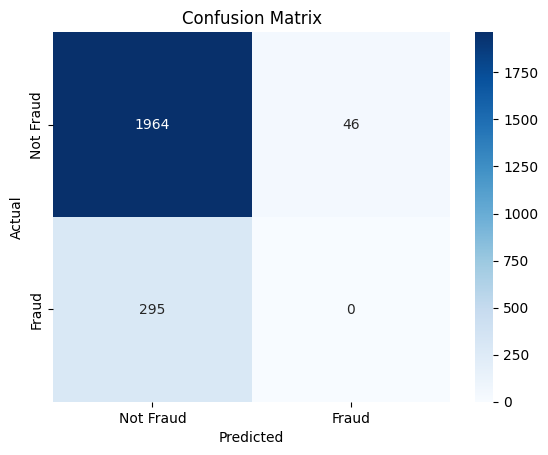

✅ ROC AUC Score: 0.4886
✅ Precision-Recall AUC: 0.0640


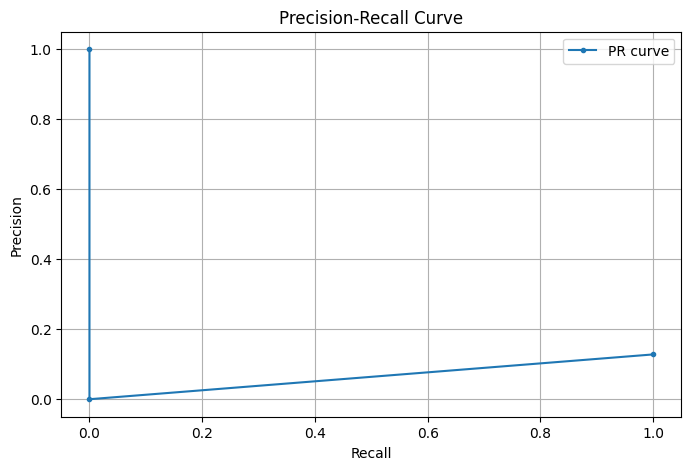

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert predictions from (-1, 1) to (1, 0): 1 for fraud, 0 for normal
y_pred_train_binary = np.where(y_pred_train == -1, 1, 0)
y_pred_test_binary = np.where(y_pred_test == -1, 1, 0)

# === METRICS on Test Set ===
print("📊 Classification Report (Test Set):")
print(classification_report(y_test, y_pred_test_binary))

print("📊 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_test_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC AUC Score
roc = roc_auc_score(y_test, y_pred_test_binary)
print(f"✅ ROC AUC Score: {roc:.4f}")

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_pred_test_binary)
pr_auc = auc(recall, precision)
print(f"✅ Precision-Recall AUC: {pr_auc:.4f}")

# === PR Curve Plot ===
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.', label='PR curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.legend()
plt.show()


Isolation forest not working

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve, roc_curve
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import EditedNearestNeighbours, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def analyze_dataset_characteristics(df, target_col='IS_FRAUD'):
    """
    Analyze the characteristics of small imbalanced dataset
    """
    print("="*80)
    print("DATASET ANALYSIS FOR SMALL IMBALANCED DATA")
    print("="*80)

    total_samples = len(df)
    fraud_samples = df[target_col].sum()
    normal_samples = total_samples - fraud_samples
    fraud_rate = fraud_samples / total_samples

    print(f"Total samples: {total_samples:,}")
    print(f"Fraud samples: {fraud_samples:,}")
    print(f"Normal samples: {normal_samples:,}")
    print(f"Fraud rate: {fraud_rate:.4f} ({fraud_rate*100:.2f}%)")
    print(f"Imbalance ratio: 1:{normal_samples/fraud_samples:.1f}")

    # Recommendations based on dataset size and imbalance
    print(f"\n{'='*80}")
    print("RECOMMENDATIONS BASED ON YOUR DATA:")
    print("="*80)

    if total_samples < 5000:
        print("✓ Small dataset detected - Use techniques optimized for small data")

    if fraud_rate < 0.05:
        print("✓ High imbalance detected - Use specialized imbalanced learning techniques")

    if fraud_samples < 50:
        print("✓ Very few fraud samples - Consider data augmentation and ensemble methods")

    return {
        'total_samples': total_samples,
        'fraud_samples': fraud_samples,
        'normal_samples': normal_samples,
        'fraud_rate': fraud_rate
    }

In [ ]:
def prepare_features_for_small_dataset(df, feature_cols, target_col='IS_FRAUD'):
    """
    Feature preparation optimized for small datasets
    """
    print("\nPreparing features for small dataset...")

    # Create a copy
    df_processed = df.copy()

    # Categorical encoding (simple for small datasets)
    categorical_cols = ['TRN_STATUS', 'RESPONSE_CODE', 'INITIATION_MODE', 'TRANSACTION_TYPE']

    for col in categorical_cols:
        if col in df_processed.columns:
            # Label encoding for small datasets (less feature explosion)
            from sklearn.preprocessing import LabelEncoder
            le = LabelEncoder()
            df_processed[f'{col}'] = le.fit_transform(df_processed[col].astype(str))

    return df_processed, feature_cols

In [ ]:

def apply_sampling_techniques(X, y, random_state=42):
    """
    Apply various sampling techniques for imbalanced small datasets
    """
    print("\nApplying sampling techniques...")

    original_distribution = Counter(y)
    print(f"Original distribution: {original_distribution}")

    sampling_results = {}

    # 1. SMOTE (Synthetic Minority Oversampling)
    try:
        smote = SMOTE(random_state=random_state)
        X_smote, y_smote = smote.fit_resample(X, y)
        sampling_results['SMOTE'] = (X_smote, y_smote)
        print(f"SMOTE: {Counter(y_smote)}")
    except Exception as e:
        print(f"SMOTE failed: {e}")

    # 2. BorderlineSMOTE (Better for small datasets)
    try:
        borderline_smote = BorderlineSMOTE(random_state=random_state)
        X_borderline, y_borderline = borderline_smote.fit_resample(X, y)
        sampling_results['BorderlineSMOTE'] = (X_borderline, y_borderline)
        print(f"BorderlineSMOTE: {Counter(y_borderline)}")
    except Exception as e:
        print(f"BorderlineSMOTE failed: {e}")

    # 3. ADASYN (Adaptive Synthetic Sampling)
    try:
        adasyn = ADASYN(random_state=random_state)
        X_adasyn, y_adasyn = adasyn.fit_resample(X, y)
        sampling_results['ADASYN'] = (X_adasyn, y_adasyn)
        print(f"ADASYN: {Counter(y_adasyn)}")
    except Exception as e:
        print(f"ADASYN failed: {e}")

    # 4. SMOTETomek (Combination of over and under sampling)
    try:
        smote_tomek = SMOTETomek(random_state=random_state)
        X_smote_tomek, y_smote_tomek = smote_tomek.fit_resample(X, y)
        sampling_results['SMOTETomek'] = (X_smote_tomek, y_smote_tomek)
        print(f"SMOTETomek: {Counter(y_smote_tomek)}")
    except Exception as e:
        print(f"SMOTETomek failed: {e}")

    return sampling_results

In [ ]:
def train_models_for_small_imbalanced_data(X, y, sampling_results):
    """
    Train multiple models optimized for small imbalanced datasets
    """
    print(f"\n{'='*80}")
    print("TRAINING MODELS FOR SMALL IMBALANCED DATA")
    print("="*80)

    models = {
        'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'Balanced Random Forest': BalancedRandomForestClassifier(n_estimators=100, random_state=42),
        'Easy Ensemble': EasyEnsembleClassifier(n_estimators=10, random_state=42),
        'SVM': SVC(probability=True, class_weight='balanced', random_state=42)
    }

    results = {}

    # Test original data
    print("Testing on original imbalanced data...")
    results['Original'] = test_models_cross_validation(models, X, y)

    # Test with different sampling techniques
    for sampling_name, (X_sampled, y_sampled) in sampling_results.items():
        print(f"\nTesting with {sampling_name}...")
        results[sampling_name] = test_models_cross_validation(models, X_sampled, y_sampled)

    return results

In [ ]:
def test_models_cross_validation(models, X, y, cv_folds=5):
    """
    Test models using cross-validation (important for small datasets)
    """
    # Use stratified k-fold for small imbalanced datasets
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    model_results = {}

    for model_name, model in models.items():
        try:
            # Cross-validation scores
            auc_scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
            pr_scores = cross_val_score(model, X, y, cv=skf, scoring='average_precision')

            model_results[model_name] = {
                'AUC_mean': auc_scores.mean(),
                'AUC_std': auc_scores.std(),
                'PR_mean': pr_scores.mean(),
                'PR_std': pr_scores.std()
            }

            print(f"{model_name:20} | AUC: {auc_scores.mean():.3f}±{auc_scores.std():.3f} | PR: {pr_scores.mean():.3f}±{pr_scores.std():.3f}")

        except Exception as e:
            print(f"{model_name:20} | Error: {e}")
            model_results[model_name] = {'AUC_mean': 0, 'AUC_std': 0, 'PR_mean': 0, 'PR_std': 0}

    return model_results

def find_best_approach(results):
    """
    Find the best model and sampling combination
    """
    print(f"\n{'='*80}")
    print("BEST PERFORMING COMBINATIONS")
    print("="*80)

    best_combinations = []

    for sampling_method, model_results in results.items():
        for model_name, scores in model_results.items():
            if scores['PR_mean'] > 0:  # Valid result
                best_combinations.append({
                    'sampling': sampling_method,
                    'model': model_name,
                    'pr_auc': scores['PR_mean'],
                    'roc_auc': scores['AUC_mean'],
                    'pr_std': scores['PR_std'],
                    'roc_std': scores['AUC_std']
                })

    # Sort by PR AUC (most important for imbalanced data)
    best_combinations.sort(key=lambda x: x['pr_auc'], reverse=True)

    print("Top 10 combinations (sorted by PR AUC):")
    print("-" * 80)
    for i, combo in enumerate(best_combinations[:10], 1):
        print(f"{i:2d}. {combo['sampling']:15} + {combo['model']:20} | "
              f"PR-AUC: {combo['pr_auc']:.3f}±{combo['pr_std']:.3f} | "
              f"ROC-AUC: {combo['roc_auc']:.3f}±{combo['roc_std']:.3f}")

    return best_combinations

def train_final_model(df, feature_cols, best_combination, target_col='IS_FRAUD'):
    """
    Train the final model using the best combination
    """
    print(f"\n{'='*80}")
    print("TRAINING FINAL MODEL")
    print("="*80)

    # Prepare data
    df_processed, updated_feature_cols = prepare_features_for_small_dataset(df, feature_cols.copy(), target_col)

    # Get features and target
    X = df_processed[updated_feature_cols]
    y = df_processed[target_col]

    # Handle categorical variables
    from sklearn.preprocessing import LabelEncoder
    for col in X.columns:
        if X[col].dtype == 'object':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

    # Scale features
    scaler = RobustScaler()  # Better for small datasets with outliers
    X_scaled = scaler.fit_transform(X)
    print("X_scaled to dataset-> ",X_scaled)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    # Apply best sampling technique
    sampling_method = best_combination['sampling']
    if sampling_method != 'Original':
        if sampling_method == 'SMOTE':
            sampler = SMOTE(random_state=42)
        elif sampling_method == 'BorderlineSMOTE':
            sampler = BorderlineSMOTE(random_state=42)
        elif sampling_method == 'ADASYN':
            sampler = ADASYN(random_state=42)
        elif sampling_method == 'SMOTETomek':
            sampler = SMOTETomek(random_state=42)

        X_train, y_train = sampler.fit_resample(X_train, y_train)

    # Train best model
    model_name = best_combination['model']
    if model_name == 'Logistic Regression':
        model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
    elif model_name == 'Random Forest':
        model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    elif model_name == 'Gradient Boosting':
        model = GradientBoostingClassifier(n_estimators=100, random_state=42)
    elif model_name == 'Balanced Random Forest':
        model = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
    elif model_name == 'Easy Ensemble':
        model = EasyEnsembleClassifier(n_estimators=10, random_state=42)
    elif model_name == 'SVM':
        model = SVC(probability=True, class_weight='balanced', random_state=42)

    # Fit model
    model.fit(X_train, y_train)

    # Predict
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    # Evaluate
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)

    print(f"Final Model Performance:")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return model, scaler, roc_auc, pr_auc

# Main execution function
def main_small_imbalanced_fraud_detection(df, feature_cols, target_col='IS_FRAUD'):
    """
    Complete pipeline for small imbalanced fraud detection
    """
    print("FRAUD DETECTION FOR SMALL IMBALANCED DATASETS")
    print("="*80)

    # 1. Analyze dataset
    stats = analyze_dataset_characteristics(df, target_col)

    # 2. Prepare features
    df_processed, updated_feature_cols = prepare_features_for_small_dataset(df, feature_cols.copy(), target_col)

    # 3. Get features and target
    X = df_processed[updated_feature_cols]
    y = df_processed[target_col]

    # Handle categorical variables
    from sklearn.preprocessing import LabelEncoder
    for col in X.columns:
        if X[col].dtype == 'object':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

    # Scale features
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    # 4. Apply sampling techniques
    sampling_results = apply_sampling_techniques(X_scaled, y)

    # 5. Train models with different sampling techniques
    results = train_models_for_small_imbalanced_data(X_scaled, y, sampling_results)

    # 6. Find best approach
    best_combinations = find_best_approach(results)

    # 7. Train final model
    if best_combinations:
        best_combo = best_combinations[0]
        print(f"\nTraining final model with: {best_combo['sampling']} + {best_combo['model']}")
        final_model, final_scaler, final_roc, final_pr = train_final_model(df, feature_cols, best_combo, target_col)

        return final_model, final_scaler, final_roc, final_pr, best_combo
    else:
        print("No valid model combinations found!")
        return None, None, 0, 0, None

# Example usage
print("Starting fraud detection for small imbalanced dataset...")

# Your feature columns
# feature_cols = [
#     'AMOUNT', 'TRN_STATUS', 'RESPONSE_CODE', 'INITIATION_MODE', 'TRANSACTION_TYPE',
#     'PAYER_VPA_freq', 'PAYER_IFSC_freq', 'PAYER_ACCOUNT_freq',
#     'BENEFICIARY_CODE_freq', 'BENEFICIARY_IFSC_freq', 'BENEFICIARY_ACCOUNT_freq',
#     'LONGITUDE_freq', 'LATITUDE_freq', 'hour', 'day_of_week',
#     'is_night', 'txn_count_1h', 'avg_amount_user', 'spending_spike',
#     'geo_distance_from_last', 'unusual_location',
#     'new_device_flag', 'is_first_transaction'
# ]

feature_cols = ['TRN_STATUS','RESPONSE_CODE', 'INITIATION_MODE', 'TRANSACTION_TYPE',
        'is_night', 'txn_count_1h',
        'spending_spike',
       'device_user_count', 'new_device_flag']

# Run the complete pipeline
final_model, final_scaler, roc_auc, pr_auc, best_combo = main_small_imbalanced_fraud_detection(df, feature_cols)

print(f"\n{'='*80}")
print("RECOMMENDATIONS FOR YOUR SMALL IMBALANCED DATASET:")
print("="*80)
print("1. Use SMOTE or BorderlineSMOTE for data augmentation")
print("2. Focus on Precision-Recall AUC (more meaningful than ROC AUC)")
print("3. Use cross-validation for reliable performance estimates")
print("4. Consider ensemble methods (Balanced Random Forest, Easy Ensemble)")
print("5. Use class_weight='balanced' in sklearn models")
print("6. Robust scaling instead of standard scaling")
print("7. Simple feature engineering (avoid overfitting)")
print("8. Collect more data if possible, especially fraud samples")

Starting fraud detection for small imbalanced dataset...
FRAUD DETECTION FOR SMALL IMBALANCED DATASETS
DATASET ANALYSIS FOR SMALL IMBALANCED DATA
Total samples: 2,881
Fraud samples: 382
Normal samples: 2,499
Fraud rate: 0.1326 (13.26%)
Imbalance ratio: 1:6.5

RECOMMENDATIONS BASED ON YOUR DATA:
✓ Small dataset detected - Use techniques optimized for small data

Preparing features for small dataset...

Applying sampling techniques...
Original distribution: Counter({0: 2499, 1: 382})
SMOTE: Counter({1: 2499, 0: 2499})
BorderlineSMOTE: Counter({1: 2499, 0: 2499})
ADASYN: Counter({0: 2499, 1: 2489})
SMOTETomek: Counter({1: 2493, 0: 2493})

TRAINING MODELS FOR SMALL IMBALANCED DATA
Testing on original imbalanced data...
Logistic Regression  | AUC: 0.781±0.022 | PR: 0.392±0.042
Random Forest        | AUC: 0.758±0.037 | PR: 0.368±0.046
Gradient Boosting    | AUC: 0.791±0.027 | PR: 0.417±0.050
Balanced Random Forest | AUC: 0.780±0.030 | PR: 0.393±0.051
Easy Ensemble        | AUC: 0.775±0.022 |

In [ ]:
final_model, final_scaler, roc_auc, pr_auc, best_combo

In [ ]:
import joblib

# Save model and scaler
joblib.dump(final_model, 'fraud_model_final_1.pkl')
joblib.dump(final_scaler, 'fraud_scaler_final_1.pkl')


# Redundant code

In [ ]:
from geopy.distance import geodesic
import pandas as pd

def generate_features(txn: dict, history_df: pd.DataFrame) -> pd.DataFrame:
    df = pd.DataFrame([txn])

    # 1. Time-based features
    df['TXN_TIMESTAMP'] = pd.to_datetime(df['TXN_TIMESTAMP'])
    df['hour'] = df['TXN_TIMESTAMP'].dt.hour
    df['day_of_week'] = df['TXN_TIMESTAMP'].dt.dayofweek
    df['is_night'] = df['hour'].apply(lambda x: 1 if x < 6 or x > 22 else 0)

    # 2. Frequency encodings
    freq_cols = [
        'PAYER_VPA', 'PAYER_IFSC', 'PAYER_ACCOUNT',
        'BENEFICIARY_CODE', 'BENEFICIARY_IFSC', 'BENEFICIARY_ACCOUNT',
        'LONGITUDE', 'LATITUDE'
    ]
    for col in freq_cols:
        if col in history_df.columns and not history_df.empty:
            freqs = history_df[col].value_counts().to_dict()
            df[f'{col}_freq'] = df[col].map(freqs).fillna(0)
        else:
            df[f'{col}_freq'] = 0  # If history is empty, default to 0

    # 3. Transactions in past 1 hour
    try:
        past_hour = history_df[
            (history_df['PAYER_VPA'] == df['PAYER_VPA'][0]) &
            (history_df['TXN_TIMESTAMP'] >= df['TXN_TIMESTAMP'][0] - pd.Timedelta(hours=1)) &
            (history_df['TXN_TIMESTAMP'] < df['TXN_TIMESTAMP'][0])
        ]
        df['txn_count_1h'] = len(past_hour)
    except:
        df['txn_count_1h'] = 0

    # 4. Average amount + spending spike
    try:
        past_user_txns = history_df[history_df['PAYER_VPA'] == df['PAYER_VPA'][0]]
        avg_amt = past_user_txns['AMOUNT'].mean() if not past_user_txns.empty else df['AMOUNT'][0]
        df['avg_amount_user'] = avg_amt
        df['spending_spike'] = int(df['AMOUNT'][0] > 3 * avg_amt)
    except:
        df['avg_amount_user'] = df['AMOUNT'][0]
        df['spending_spike'] = 0

    # 5. Geolocation jump
    try:
        past_txn = past_user_txns.sort_values(by='TXN_TIMESTAMP').iloc[-1:]
        if not past_txn.empty:
            prev_coords = (past_txn['LATITUDE'].values[0], past_txn['LONGITUDE'].values[0])
            this_coords = (df['LATITUDE'][0], df['LONGITUDE'][0])
            dist = geodesic(this_coords, prev_coords).km
            df['geo_distance_from_last'] = dist
            df['unusual_location'] = int(dist > 100)
        else:
            df['geo_distance_from_last'] = 0
            df['unusual_location'] = 0
    except:
        df['geo_distance_from_last'] = 0
        df['unusual_location'] = 0

    # 6. Device behavior
    try:
        prev_devices = past_user_txns['DEVICE_ID'].unique()
        df['new_device_flag'] = int(df['DEVICE_ID'][0] not in prev_devices)
    except:
        df['new_device_flag'] = 1  # Assume new device if no past data

    # 7. First transaction flag
    try:
        df['is_first_transaction'] = int(len(past_user_txns) == 0)
    except:
        df['is_first_transaction'] = 1

    return df[[
        'AMOUNT', 'TRN_STATUS', 'RESPONSE_CODE', 'INITIATION_MODE', 'TRANSACTION_TYPE',
        'PAYER_VPA_freq', 'PAYER_IFSC_freq', 'PAYER_ACCOUNT_freq',
        'BENEFICIARY_CODE_freq', 'BENEFICIARY_IFSC_freq', 'BENEFICIARY_ACCOUNT_freq',
        'LONGITUDE_freq', 'LATITUDE_freq', 'hour', 'day_of_week',
        'is_night', 'txn_count_1h', 'avg_amount_user', 'spending_spike',
        'geo_distance_from_last', 'unusual_location',
        'new_device_flag', 'is_first_transaction'
    ]]


In [ ]:
feature_cols = [
    'AMOUNT', 'TRN_STATUS', 'RESPONSE_CODE', 'INITIATION_MODE', 'TRANSACTION_TYPE',
    'PAYER_VPA_freq', 'PAYER_IFSC_freq', 'PAYER_ACCOUNT_freq',
    'BENEFICIARY_CODE_freq', 'BENEFICIARY_IFSC_freq', 'BENEFICIARY_ACCOUNT_freq',
    'LONGITUDE_freq', 'LATITUDE_freq', 'hour', 'day_of_week',
    'is_night', 'txn_count_1h', 'avg_amount_user', 'spending_spike',
    'geo_distance_from_last', 'unusual_location',
    'new_device_flag', 'is_first_transaction'
]

In [ ]:
txn_input = {
    'TXN_TIMESTAMP': '2025-05-22 14:32',
    'AMOUNT': 6000,
    'TRN_STATUS': 1,
    'RESPONSE_CODE': 0,
    'INITIATION_MODE': 2,
    'TRANSACTION_TYPE': 1,
    'PAYER_VPA': 'abc@upi',
    'PAYER_IFSC': 'SBIN0001',
    'PAYER_ACCOUNT': '123456',
    'BENEFICIARY_CODE': 'BENE1',
    'BENEFICIARY_IFSC': 'HDFC0001',
    'BENEFICIARY_ACCOUNT': '654321',
    'LONGITUDE': 77.12,
    'LATITUDE': 28.61,
    'DEVICE_ID': 'dev123'
}



In [ ]:
import pandas as pd
from datetime import datetime, timedelta

history_data = [
    {
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=7),
        'AMOUNT': 500,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,
        'TRANSACTION_TYPE': 1,
        'PAYER_VPA': 'user1@upi',
        'PAYER_IFSC': 'SBIN0001',
        'PAYER_ACCOUNT': '123456',
        'BENEFICIARY_CODE': 'BENE123',
        'BENEFICIARY_IFSC': 'HDFC0001',
        'BENEFICIARY_ACCOUNT': '987654',
        'LONGITUDE': 77.10,
        'LATITUDE': 28.61,
        'DEVICE_ID': 'device_001'
    },
    {
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=5),
        'AMOUNT': 1200,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,
        'TRANSACTION_TYPE': 1,
        'PAYER_VPA': 'user1@upi',
        'PAYER_IFSC': 'SBIN0001',
        'PAYER_ACCOUNT': '123456',
        'BENEFICIARY_CODE': 'BENE789',
        'BENEFICIARY_IFSC': 'ICIC0002',
        'BENEFICIARY_ACCOUNT': '543210',
        'LONGITUDE': 77.11,
        'LATITUDE': 28.62,
        'DEVICE_ID': 'device_001'
    },
    {
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=4),
        'AMOUNT': 1200,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,
        'TRANSACTION_TYPE': 1,
        'PAYER_VPA': 'user1@upi',
        'PAYER_IFSC': 'SBIN0001',
        'PAYER_ACCOUNT': '123456',
        'BENEFICIARY_CODE': 'BENE789',
        'BENEFICIARY_IFSC': 'ICIC0002',
        'BENEFICIARY_ACCOUNT': '543210',
        'LONGITUDE': 77.11,
        'LATITUDE': 28.62,
        'DEVICE_ID': 'device_001'
    },
    {
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=4),
        'AMOUNT': 1200,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,
        'TRANSACTION_TYPE': 1,
        'PAYER_VPA': 'user1@upi',
        'PAYER_IFSC': 'SBIN0001',
        'PAYER_ACCOUNT': '123456',
        'BENEFICIARY_CODE': 'BENE789',
        'BENEFICIARY_IFSC': 'ICIC0002',
        'BENEFICIARY_ACCOUNT': '543210',
        'LONGITUDE': 77.11,
        'LATITUDE': 28.62,
        'DEVICE_ID': 'device_001'
    },
    {
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=3),
        'AMOUNT': 1200,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,
        'TRANSACTION_TYPE': 1,
        'PAYER_VPA': 'user1@upi',
        'PAYER_IFSC': 'SBIN0001',
        'PAYER_ACCOUNT': '123456',
        'BENEFICIARY_CODE': 'BENE789',
        'BENEFICIARY_IFSC': 'ICIC0002',
        'BENEFICIARY_ACCOUNT': '543210',
        'LONGITUDE': 77.11,
        'LATITUDE': 28.62,
        'DEVICE_ID': 'device_001'
    },
    {
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=2),
        'AMOUNT': 1200,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,
        'TRANSACTION_TYPE': 1,
        'PAYER_VPA': 'user1@upi',
        'PAYER_IFSC': 'SBIN0001',
        'PAYER_ACCOUNT': '123456',
        'BENEFICIARY_CODE': 'BENE789',
        'BENEFICIARY_IFSC': 'ICIC0002',
        'BENEFICIARY_ACCOUNT': '543210',
        'LONGITUDE': 77.11,
        'LATITUDE': 28.62,
        'DEVICE_ID': 'device_001'
    },
    {
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=1),
        'AMOUNT': 1200,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,
        'TRANSACTION_TYPE': 1,
        'PAYER_VPA': 'user1@upi',
        'PAYER_IFSC': 'SBIN0001',
        'PAYER_ACCOUNT': '123456',
        'BENEFICIARY_CODE': 'BENE789',
        'BENEFICIARY_IFSC': 'ICIC0002',
        'BENEFICIARY_ACCOUNT': '543210',
        'LONGITUDE': 77.11,
        'LATITUDE': 28.62,
        'DEVICE_ID': 'device_001'
    }
]



In [ ]:
txn_input = {
    'TXN_TIMESTAMP': datetime.now(),
    'AMOUNT': 5000,
    'TRN_STATUS': 1,
    'RESPONSE_CODE': 0,
    'INITIATION_MODE': 1,
    'TRANSACTION_TYPE': 1,
    'PAYER_VPA': 'newuser@upi',
    'PAYER_IFSC': 'SBIN0009',
    'PAYER_ACCOUNT': '000999',
    'BENEFICIARY_CODE': 'BENE777',
    'BENEFICIARY_IFSC': 'PNB0002',
    'BENEFICIARY_ACCOUNT': '111222',
    'LONGITUDE': 0.10,
    'LATITUDE': 0.40,
    'DEVICE_ID': 'new_device'
}
# ❌ Expected: Suspicious (new user, new device, big amount)


In [ ]:
import joblib

# Load saved model and scaler
final_model = joblib.load('fraud_model.pkl')
final_scaler = joblib.load('fraud_scaler.pkl')

In [ ]:


# Assume `txn_input` is the new incoming transaction as a dictionary
# and `history_df` is the full transaction log as a DataFrame

history_df = pd.DataFrame(history_df)

df_test = generate_features(txn_input, history_df)
df_processed, updated_feature_cols = prepare_features_for_small_dataset(df_test, feature_cols.copy(), 'IS_FRAUD')

# 3. Get features and target
X = df_processed[updated_feature_cols]

X_scaled = final_scaler.transform(X)

# Predict fraud (1 = fraud, 0 = legit)
y_pred_proba = final_model.predict_proba(X_scaled)[:, 1]
y_pred = final_model.predict(X_scaled)

print("Fraud?", y_pred, "| Probability:", y_pred_proba)


In [ ]:
X.columns

In [ ]:
X_scaled

# Testing

In [ ]:
from geopy.distance import geodesic
import pandas as pd

def generate_features(txn: dict, history_df: pd.DataFrame) -> pd.DataFrame:
    df = pd.DataFrame([txn])

    # 1. Time-based features
    df['TXN_TIMESTAMP'] = pd.to_datetime(df['TXN_TIMESTAMP'])
    df['hour'] = df['TXN_TIMESTAMP'].dt.hour
    df['day_of_week'] = df['TXN_TIMESTAMP'].dt.dayofweek
    df['is_night'] = df['hour'].apply(lambda x: 1 if x < 6 or x > 22 else 0)

    # # 2. Frequency encodings
    # freq_cols = [
    #     'PAYER_VPA', 'PAYER_IFSC', 'PAYER_ACCOUNT',
    #     'BENEFICIARY_CODE', 'BENEFICIARY_IFSC', 'BENEFICIARY_ACCOUNT',
    #     'LONGITUDE', 'LATITUDE'
    # ]
    # for col in freq_cols:
    #     if col in history_df.columns and not history_df.empty:
    #         freqs = history_df[col].value_counts().to_dict()
    #         df[f'{col}_freq'] = df[col].map(freqs).fillna(0)
    #     else:
    #         df[f'{col}_freq'] = 0  # If history is empty, default to 0

    # 3. Transactions in past 1 hour
    try:
        past_hour = history_df[
            (history_df['PAYER_VPA'] == df['PAYER_VPA'][0]) &
            (history_df['TXN_TIMESTAMP'] >= df['TXN_TIMESTAMP'][0] - pd.Timedelta(hours=1)) &
            (history_df['TXN_TIMESTAMP'] < df['TXN_TIMESTAMP'][0])
        ]
        df['txn_count_1h'] = len(past_hour)
    except:
        df['txn_count_1h'] = 0

    # 4. Average amount + spending spike
    try:
        past_user_txns = history_df[history_df['PAYER_VPA'] == df['PAYER_VPA'][0]]
        avg_amt = past_user_txns['AMOUNT'].mean() if not past_user_txns.empty else df['AMOUNT'][0]
        df['avg_amount_user'] = avg_amt
        df['spending_spike'] = int((df['AMOUNT'][0] > 3 * avg_amt))
    except:
        df['avg_amount_user'] = df['AMOUNT'][0]
        df['spending_spike'] = 0

    # # 5. Geolocation jump
    # try:
    #     past_txn = past_user_txns.sort_values(by='TXN_TIMESTAMP').iloc[-1:]
    #     if not past_txn.empty:
    #         prev_coords = (past_txn['LATITUDE'].values[0], past_txn['LONGITUDE'].values[0])
    #         this_coords = (df['LATITUDE'][0], df['LONGITUDE'][0])
    #         dist = geodesic(this_coords, prev_coords).km
    #         df['geo_distance_from_last'] = dist
    #         df['unusual_location'] = int(dist > 100)
    #     else:
    #         df['geo_distance_from_last'] = 0
    #         df['unusual_location'] = 0
    # except:
    #     df['geo_distance_from_last'] = 0
    #     df['unusual_location'] = 0

    # 6. Device behavior
    try:
        prev_devices = past_user_txns['DEVICE_ID'].unique()
        df['new_device_flag'] = int(df['DEVICE_ID'][0] not in prev_devices)
    except:
        df['new_device_flag'] = 1  # Assume new device if no past data

    try:
      device_user_counts = df.groupby('DEVICE_ID')['PAYER_VPA'].nunique()
      df['device_user_count'] = df['DEVICE_ID'].map(device_user_counts)
    except:
        df['device_user_count'] = 1

    # # 7. First transaction flag
    # try:
    #     df['is_first_transaction'] = int(len(past_user_txns) == 0)
    # except:
    #     df['is_first_transaction'] = 1

    # return df[[
    #     'TRN_STATUS','RESPONSE_CODE', 'INITIATION_MODE', 'TRANSACTION_TYPE',
    #     'is_night', 'txn_count_1h','day_of_week',
    #    'avg_amount_user', 'spending_spike',
    #    'device_user_count', 'new_device_flag'
    # ]]

    return df[[
            'TRN_STATUS','RESPONSE_CODE', 'INITIATION_MODE', 'TRANSACTION_TYPE',
            'is_night', 'txn_count_1h',
           'spending_spike',
          'device_user_count', 'new_device_flag'
        ]]

In [ ]:
import pandas as pd
from datetime import datetime, timedelta

history_df = pd.DataFrame([
    {
        'PAYER_VPA': 'userX@upi',
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=10),
        'AMOUNT': 200.0,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,       # QR
        'TRANSACTION_TYPE': 1,      # P2P
        'DEVICE_ID': 'deviceA'
    },
    {
        'PAYER_VPA': 'userX@upi',
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=10.1),
        'AMOUNT': 250.0,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,
        'TRANSACTION_TYPE': 1,
        'DEVICE_ID': 'deviceA'
    },
    {
        'PAYER_VPA': 'userX@upi',
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=10.2),
        'AMOUNT': 300.0,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,
        'TRANSACTION_TYPE': 2,      # Merchant
        'DEVICE_ID': 'deviceA'
    },
])


txn_input_A = {
    'PAYER_VPA': 'userX@upi',
    'TXN_TIMESTAMP': datetime.now().strftime('%d-%m-%Y %H:%M'),
    'AMOUNT': 220.0,            # close to history average
    'TRN_STATUS': 1,
    'RESPONSE_CODE': 0,
    'INITIATION_MODE': 1,
    'TRANSACTION_TYPE': 1,
    'DEVICE_ID': 'deviceA'
}
# Expected: Normal (0)
txn_input_B = {
    'PAYER_VPA': 'userX@upi',
    'TXN_TIMESTAMP': datetime.now().replace(hour=18, minute=30).strftime('%d-%m-%Y %H:%M'),
    'AMOUNT': 280.0,
    'TRN_STATUS': 1,
    'RESPONSE_CODE': 0,
    'INITIATION_MODE': 2,       # BBPS
    'TRANSACTION_TYPE': 2,
    'DEVICE_ID': 'deviceA'
}
# Expected: Normal (0)
txn_input_C = {
    'PAYER_VPA': 'userX@upi',
    'TXN_TIMESTAMP': datetime.now().replace(hour=23, minute=45).strftime('%d-%m-%Y %H:%M'),
    'AMOUNT': 150.0,
    'TRN_STATUS': 1,
    'RESPONSE_CODE': 0,
    'INITIATION_MODE': 1,
    'TRANSACTION_TYPE': 1,
    'DEVICE_ID': 'deviceA'
}
# Expected: Normal (0) – small amount though is_night=1
txn_input_D = {
    'PAYER_VPA': 'userX@upi',
    'TXN_TIMESTAMP': datetime.now().strftime('%d-%m-%Y %H:%M'),
    'AMOUNT': 6000.0,           # >> 3× history avg (~250)
    'TRN_STATUS': 1,
    'RESPONSE_CODE': 0,
    'INITIATION_MODE': 1,
    'TRANSACTION_TYPE': 1,
    'DEVICE_ID': 'deviceA'
}
# Expected: Fraud (1) due to spending_spike
txn_input_E = {
    'PAYER_VPA': 'userX@upi',
    'TXN_TIMESTAMP': datetime.now().strftime('%d-%m-%Y %H:%M'),
    'AMOUNT': 250.0,
    'TRN_STATUS': 1,
    'RESPONSE_CODE': 0,
    'INITIATION_MODE': 1,
    'TRANSACTION_TYPE': 1,
    'DEVICE_ID': 'deviceA',
    'LATITUDE': 12.97,          # previous ~28.6, big jump
    'LONGITUDE': 77.59
}
# Expected: Fraud (1) due to geo_distance_from_last >> threshold
txn_input_F = {
    'PAYER_VPA': 'userX@upi',
    'TXN_TIMESTAMP': datetime.now().replace(hour=2, minute=10).strftime('%d-%m-%Y %H:%M'),
    'AMOUNT': 270.0,
    'TRN_STATUS': 1,
    'RESPONSE_CODE': 0,
    'INITIATION_MODE': 1,
    'TRANSACTION_TYPE': 1,
    'DEVICE_ID': 'deviceZ'      # never seen in history
}
# Expected: Fraud (1) due to new_device_flag=1 and is_night=1


In [ ]:
import pandas as pd
from datetime import datetime, timedelta

# History of past transactions for userA
history_df = pd.DataFrame([
    {
        'PAYER_VPA': 'userA@upi',
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=5),
        'AMOUNT': 120.0,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,         # e.g. QR
        'TRANSACTION_TYPE': 1,        # e.g. P2P
        'DEVICE_ID': 'dev123'
    },
    {
        'PAYER_VPA': 'userA@upi',
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=3),
        'AMOUNT': 80.0,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,
        'TRANSACTION_TYPE': 1,
        'DEVICE_ID': 'dev123'
    },
    {
        'PAYER_VPA': 'userA@upi',
        'TXN_TIMESTAMP': datetime.now() - timedelta(hours=1, minutes=30),
        'AMOUNT': 100.0,
        'TRN_STATUS': 1,
        'RESPONSE_CODE': 0,
        'INITIATION_MODE': 1,
        'TRANSACTION_TYPE': 1,
        'DEVICE_ID': 'dev123'
    }
])

# New transaction to test
txn_input = {
    'PAYER_VPA': 'userA@upi',
    'TXN_TIMESTAMP': datetime.now().strftime('%d-%m-%Y %H:%M'),
    'AMOUNT': 90.0,
    'TRN_STATUS': 1,
    'RESPONSE_CODE': 0,
    'INITIATION_MODE': 1,
    'TRANSACTION_TYPE': 1,
    'DEVICE_ID': 'dev123'
}

# Reuse same history_df as Case 1

# New high-value transaction (5× avg)
txn_input_fraud = {
    'PAYER_VPA': 'userA@upi',
    'TXN_TIMESTAMP': datetime.now().strftime('%d-%m-%Y %H:%M'),
    'AMOUNT': 60000.0,  # avg is ~100, so 6× spike
    'TRN_STATUS': 1,
    'RESPONSE_CODE': 0,
    'INITIATION_MODE': 1,
    'TRANSACTION_TYPE': 1,
    'DEVICE_ID': 'dev12387'
}

# Expected: model should flag **fraud** (1) due to spending_spike.


# Expected: model should predict **normal** (0).


In [ ]:
import joblib

# Load saved model and scaler
final_model = joblib.load('fraud_model_final_1.pkl')
final_scaler = joblib.load('fraud_scaler_final_1.pkl')

In [ ]:

# Assume `txn_input` is the new incoming transaction as a dictionary
# and `history_df` is the full transaction log as a DataFrame

history_df = pd.DataFrame(history_df)

df_test = generate_features(txn_input_D, history_df)
df_processed, updated_feature_cols = prepare_features_for_small_dataset(df_test, feature_cols.copy(), 'IS_FRAUD')

# 3. Get features and target
X = df_processed[updated_feature_cols]

X_scaled = final_scaler.transform(X)

# Predict fraud (1 = fraud, 0 = legit)
y_pred_proba = final_model.predict_proba(X)[:, 1]
y_pred = final_model.predict(X)

print("Fraud?", y_pred, "| Probability:", y_pred_proba)


Preparing features for small dataset...


KeyError: "['AMOUNT', 'PAYER_VPA_freq', 'PAYER_IFSC_freq', 'PAYER_ACCOUNT_freq', 'BENEFICIARY_CODE_freq', 'BENEFICIARY_IFSC_freq', 'BENEFICIARY_ACCOUNT_freq', 'LONGITUDE_freq', 'LATITUDE_freq', 'hour', 'day_of_week', 'avg_amount_user', 'geo_distance_from_last', 'unusual_location', 'is_first_transaction'] not in index"

In [ ]:
X

In [ ]:
X_scaled.shape